In [1]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from timeseries import read_timeseries_csv

zone = "centro_sud"
year = 2020

solar_cf = read_timeseries_csv(PROJECT_ROOT / "data" / "processed" / "solar" / zone / f"solar_cf_{year}.csv")
wind_cf = read_timeseries_csv(PROJECT_ROOT / "data" / "processed" / "wind" / zone / f"wind_cf_{year}.csv")

solar_cf.head()

,solar_cf
valid_time,
2020-01-01 00:00:00+01:00,0.0
2020-01-01 00:15:00+01:00,0.0
2020-01-01 00:30:00+01:00,0.0
2020-01-01 00:45:00+01:00,0.0
2020-01-01 01:00:00+01:00,0.0


count    35136.000000
mean         0.205934
std          0.282006
min          0.000000
25%          0.000000
50%          0.000000
75%          0.423162
max          0.960000
Name: solar_cf, dtype: float64
count    35136.000000
mean         0.128429
std          0.203103
min          0.000000
25%          0.001714
50%          0.034471
75%          0.168878
max          0.983607
Name: wind_cf, dtype: float64


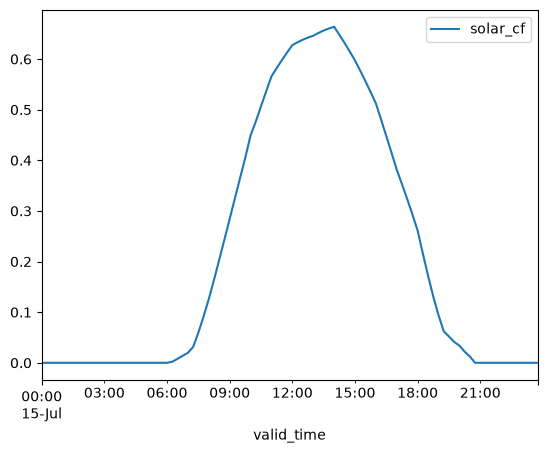

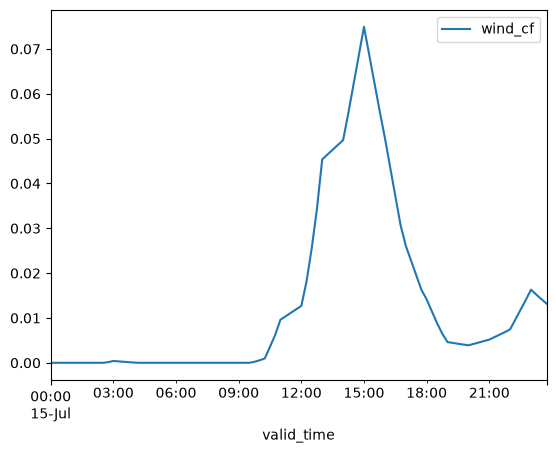

In [2]:
import matplotlib.pyplot as plt

print(solar_cf["solar_cf"].describe())
print(wind_cf["wind_cf"].describe())

solar_cf.loc["2020-07-15"].plot(label="solar")
wind_cf.loc["2020-07-15"].plot(label="wind")
plt.legend()
plt.show()

In [3]:
import yaml

with open(PROJECT_ROOT / "config.yaml") as f:
    config = yaml.safe_load(f)

START_YEAR = config["weather"]["start_year"]
END_YEAR = config["weather"]["end_year"]

price_scenarios = {
    "placeholder_low": 90,
    "placeholder_mid": 100,
    "placeholder_high": 110,
}

scenario_matrix = [
    {"weather_year": year, "price_scenario": name, "price_eur_mwh": price}
    for year in range(START_YEAR, END_YEAR + 1)
    for name, price in price_scenarios.items()
]

scenario_df = pd.DataFrame(scenario_matrix)
print(len(scenario_df))
scenario_df.head(6)

99


,weather_year,price_scenario,price_eur_mwh
0,1991,placeholder_low,90
1,1991,placeholder_mid,100
2,1991,placeholder_high,110
3,1992,placeholder_low,90
4,1992,placeholder_mid,100
5,1992,placeholder_high,110


33


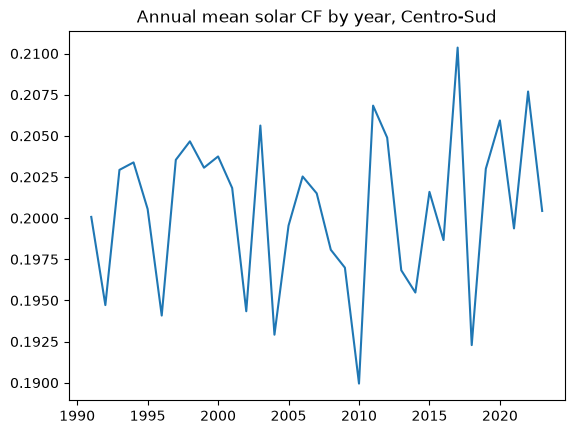

In [4]:
cf_by_year = {}

for y in range(START_YEAR, END_YEAR + 1):
    solar = read_timeseries_csv(PROJECT_ROOT / "data" / "processed" / "solar" / zone / f"solar_cf_{y}.csv")
    wind = read_timeseries_csv(PROJECT_ROOT / "data" / "processed" / "wind" / zone / f"wind_cf_{y}.csv")
    cf_by_year[y] = {"solar_cf": solar["solar_cf"], "wind_cf": wind["wind_cf"]}

print(len(cf_by_year))
pd.Series({y: data["solar_cf"].mean() for y, data in cf_by_year.items()}).plot(title="Annual mean solar CF by year, Centro-Sud")
plt.show()